# Assignment 2 — Optimization Methods

- **Q1:** Steepest Descent Method with Exact Line Search
- **Q2:** Gradient Descent and Adam on $g(w)=(w-1.5)^2$
- **Q3:** AdaGrad vs RMSProp on $f(x_1,x_2)=x_1^4+16x_2^4-8x_1x_2$

Only NumPy, Pandas and Matplotlib are used — no `scipy.optimize` or any library that performs the line search / descent step.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
pd.set_option('display.float_format', lambda x: f'{x:.6f}')

---
## Q1 — Steepest Descent Method with Exact Line Search

$$J(w) = \tfrac12 w^TAw - b^Tw,\qquad A=\begin{bmatrix}4&1\\1&2\end{bmatrix},\ \ b=\begin{bmatrix}1\\2\end{bmatrix}$$

**1. Gradient:** $\nabla J(w) = Aw - b$

**2. Steepest descent direction:** $g_t = -\nabla J(w_t)$

**3. Exact step size.** Since $J$ is quadratic, minimizing $J(w_t+\alpha g_t)$ over $\alpha$ has a closed form:
$$\frac{d}{d\alpha}J(w_t+\alpha g_t) = -g_t^Tg_t + \alpha\, g_t^TAg_t = 0 \ \Longrightarrow\ \alpha_t = \frac{g_t^Tg_t}{g_t^TAg_t}$$

**4. Update:** $w_{t+1} = w_t + \alpha_t g_t$, repeated until $\|\nabla J(w)\|<10^{-6}$.

In [ ]:
A = np.array([[4.0, 1.0],
              [1.0, 2.0]])
b = np.array([1.0, 2.0])

def J(w):
    return 0.5 * w @ A @ w - b @ w

def grad(w):
    return A @ w - b   # gradient of J

In [ ]:
w = np.array([0.0, 0.0])          # w0
tol = 1e-6

J_hist = [J(w)]
gnorm_hist = [np.linalg.norm(grad(w))]
w_hist = [w.copy()]

k = 0
while True:
    g_k = grad(w)                  # grad J(w_t)
    gnorm = np.linalg.norm(g_k)
    if gnorm < tol:
        break

    d = -g_k                       # steepest descent direction g_t

    # exact line search: alpha* = (d^T d) / (d^T A d)
    Ad = A @ d
    alpha = (d @ d) / (d @ Ad)

    w = w + alpha * d
    k += 1

    J_hist.append(J(w))
    gnorm_hist.append(np.linalg.norm(grad(w)))
    w_hist.append(w.copy())

print("Optimal solution  w* =", w)
print("Closed form check  A^-1 b =", np.linalg.solve(A, b))
print("J(w*) =", J(w))
print("Total number of iterations =", k)
print("Final gradient norm =", np.linalg.norm(grad(w)))

Optimal solution  w* = [2.11758237e-22 9.99999749e-01]
Closed form check  A^-1 b = [0. 1.]
J(w*) = -0.999999999999937
Total number of iterations = 20
Final gradient norm = 5.610035624716221e-07


**7. Verify $g_t^T \nabla J(w_{t+1}) \approx 0$** — this is the first-order optimality condition of an exact line search along $g_t$ (the new gradient must be orthogonal to the direction just used).

In [ ]:
checks = []
for t in range(len(w_hist)-1):
    g_t = -grad(w_hist[t])            # direction used at step t
    checks.append(g_t @ grad(w_hist[t+1]))

print("g_t^T * grad(w_(t+1)) for t = 0 .. T-1:")
for t, c in enumerate(checks):
    print(f"  t={t:2d}:  {c: .3e}")

g_t^T * grad(w_(t+1)) for t = 0 .. T-1:
  t= 0:   0.000e+00
  t= 1:   0.000e+00
  t= 2:   0.000e+00
  t= 3:   0.000e+00
  t= 4:   0.000e+00
  t= 5:   0.000e+00
  t= 6:   0.000e+00
  t= 7:   0.000e+00
  t= 8:   0.000e+00
  t= 9:   0.000e+00
  t=10:   0.000e+00
  t=11:   0.000e+00
  t=12:   0.000e+00
  t=13:   0.000e+00
  t=14:   0.000e+00
  t=15:   0.000e+00
  t=16:   0.000e+00
  t=17:   0.000e+00
  t=18:   0.000e+00
  t=19:   0.000e+00


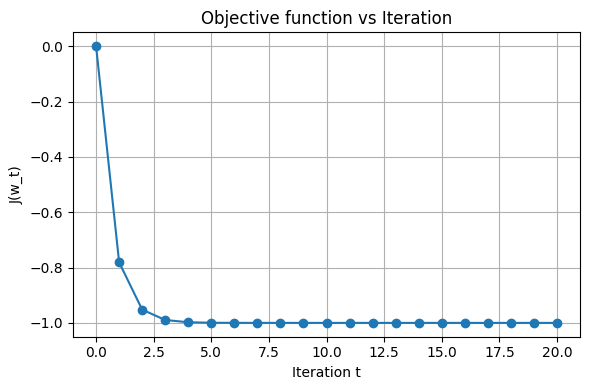

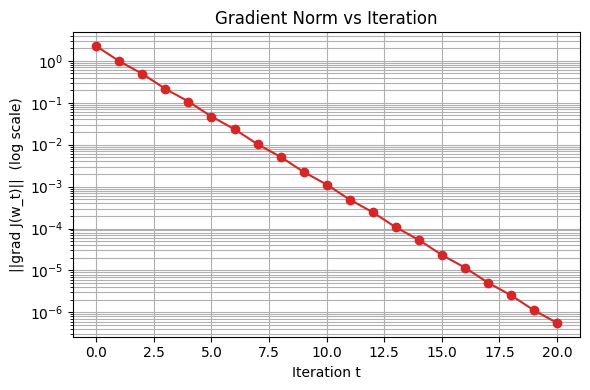

In [ ]:
iters = np.arange(len(J_hist))

plt.figure(figsize=(6,4))
plt.plot(iters, J_hist, marker='o')
plt.xlabel("Iteration t"); plt.ylabel("J(w_t)")
plt.title("Objective function vs Iteration")
plt.grid(True); plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
plt.semilogy(iters, gnorm_hist, marker='o', color='tab:red')
plt.xlabel("Iteration t"); plt.ylabel("||grad J(w_t)||  (log scale)")
plt.title("Gradient Norm vs Iteration")
plt.grid(True, which='both'); plt.tight_layout()
plt.show()

In [ ]:
q1_table = pd.DataFrame(w_hist, columns=['w1','w2'])
q1_table['J(w)'] = J_hist
q1_table['||grad J||'] = gnorm_hist
q1_table.index.name = 'iter'
q1_table

,w1,w2,J(w),||grad J||
iter,,,,
0,0.000000,0.000000,0.000000,2.236068
1,0.312500,0.625000,-0.781250,0.978280
2,0.000000,0.781250,-0.952148,0.489140
3,0.068359,0.917969,-0.989532,0.213999
4,0.000000,0.952148,-0.997710,0.106999
5,0.014954,0.982056,-0.999499,0.046812
6,0.000000,0.989532,-0.999890,0.023406
7,0.003271,0.996075,-0.999976,0.010240
8,0.000000,0.997710,-0.999995,0.005120


---
## Q2 — Gradient Descent and Adam on $g(w)=(w-1.5)^2$

### Part 1 — Gradient Descent iteration

$g'(w) = 2(w-1.5)$, learning rate $\eta=0.2$:
$$w_{k+1} = w_k - \eta\, g'(w_k) = w_k - 0.4(w_k-1.5) = 0.6\,w_k + 0.6$$
which is a linear contraction toward $w^\*=1.5$: $\ w_k - 1.5 = 0.6^k(w_0-1.5)$.

### Part 2 — 10 iterations of Gradient Descent

In [ ]:
def g(w):
    return (w - 1.5)**2

def g_grad(w):
    return 2.0*(w - 1.5)

eta = 0.2
w = 2.0
gd_rows = [(0, w, g(w))]
for k in range(1, 11):
    w = w - eta * g_grad(w)
    gd_rows.append((k, w, g(w)))

gd_table = pd.DataFrame(gd_rows, columns=['k', 'w_k', 'g(w_k)']).set_index('k')
gd_table

,w_k,g(w_k)
k,,
0,2.000000,0.250000
1,1.800000,0.090000
2,1.680000,0.032400
3,1.608000,0.011664
4,1.564800,0.004199
5,1.538880,0.001512
6,1.523328,0.000544
7,1.513997,0.000196
8,1.508398,0.000071


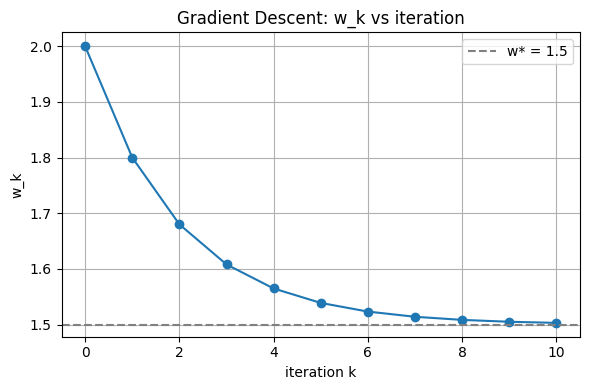

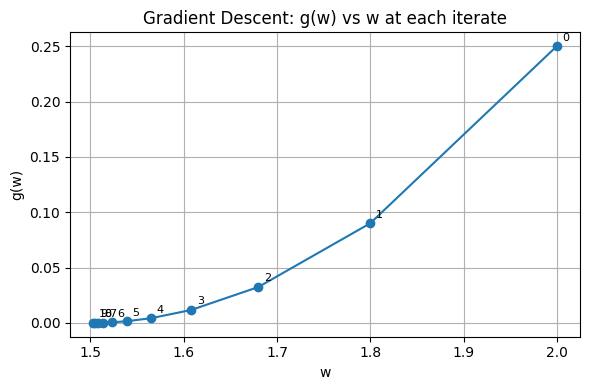

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(gd_table.index, gd_table['w_k'], marker='o')
plt.axhline(1.5, color='gray', linestyle='--', label='w* = 1.5')
plt.xlabel('iteration k'); plt.ylabel('w_k')
plt.title('Gradient Descent: w_k vs iteration'); plt.legend(); plt.grid(True)
plt.tight_layout(); plt.show()

plt.figure(figsize=(6,4))
plt.plot(gd_table['w_k'], gd_table['g(w_k)'], marker='o')
for k, row in gd_table.iterrows():
    plt.annotate(str(k), (row['w_k'], row['g(w_k)']), textcoords="offset points", xytext=(4,4), fontsize=8)
plt.xlabel('w'); plt.ylabel('g(w)')
plt.title('Gradient Descent: g(w) vs w at each iterate'); plt.grid(True)
plt.tight_layout(); plt.show()

### Part 3 — Adam iteration (with bias-corrected learning rate $\alpha_t$)

Using $\rho_1=0.9$ (first-moment decay, "$\rho_f$" in the question) and $\rho_2=0.999$ (second-moment decay, "$\rho$" in the question):

$$m_k=\rho_1 m_{k-1}+(1-\rho_1)g_k, \qquad v_k=\rho_2 v_{k-1}+(1-\rho_2)g_k^2$$
$$\alpha_k=\alpha\,\frac{\sqrt{1-\rho_2^{\,k}}}{1-\rho_1^{\,k}}\quad\text{(bias-corrected learning rate)}$$
$$w_k = w_{k-1} - \alpha_k\,\frac{m_k}{\sqrt{v_k}+\epsilon}$$

### Part 4 — 10 iterations of Adam

In [ ]:
alpha = 0.2
rho1 = 0.9      # rho_f
rho2 = 0.999    # rho
eps = 1e-8

w = 2.0
m = 0.0
v = 0.0
adam_rows = [(0, w, np.nan, g(w))]

for k in range(1, 11):
    grd = g_grad(w)
    m = rho1*m + (1-rho1)*grd
    v = rho2*v + (1-rho2)*grd*grd
    alpha_t = alpha * np.sqrt(1 - rho2**k) / (1 - rho1**k)
    w = w - alpha_t * m / (np.sqrt(v) + eps)
    adam_rows.append((k, w, alpha_t, g(w)))

adam_table = pd.DataFrame(adam_rows, columns=['k', 'w_k', 'alpha_k', 'g(w_k)']).set_index('k')
adam_table

,w_k,alpha_k,g(w_k)
k,,,
0,2.000000,NaN,0.250000
1,1.800000,0.063246,0.090000
2,1.608502,0.047063,0.011773
3,1.439583,0.040402,0.003650
4,1.313724,0.036754,0.034699
5,1.244792,0.034500,0.065131
6,1.229383,0.033022,0.073233
7,1.254674,0.032026,0.060185
8,1.307569,0.031354,0.037030


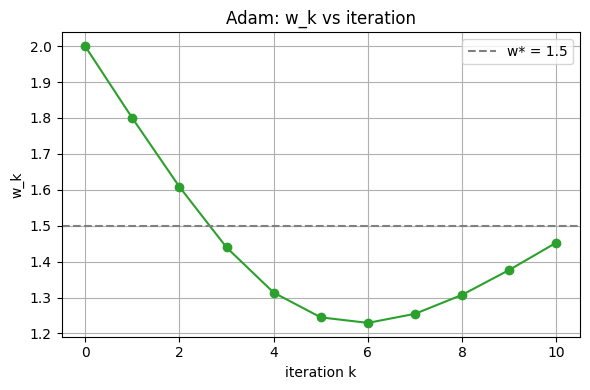

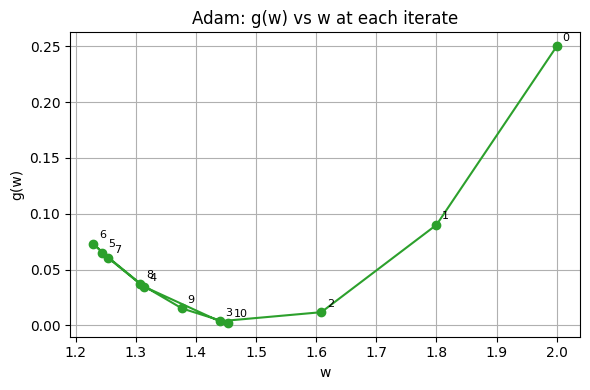

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(adam_table.index, adam_table['w_k'], marker='o', color='tab:green')
plt.axhline(1.5, color='gray', linestyle='--', label='w* = 1.5')
plt.xlabel('iteration k'); plt.ylabel('w_k')
plt.title('Adam: w_k vs iteration'); plt.legend(); plt.grid(True)
plt.tight_layout(); plt.show()

plt.figure(figsize=(6,4))
plt.plot(adam_table['w_k'], adam_table['g(w_k)'], marker='o', color='tab:green')
for k, row in adam_table.iterrows():
    plt.annotate(str(k), (row['w_k'], row['g(w_k)']), textcoords="offset points", xytext=(4,4), fontsize=8)
plt.xlabel('w'); plt.ylabel('g(w)')
plt.title('Adam: g(w) vs w at each iterate'); plt.grid(True)
plt.tight_layout(); plt.show()

---
## Q3 — AdaGrad vs RMSProp on $f(x_1,x_2)=x_1^4+16x_2^4-8x_1x_2$

### Part 1 — Curvature comment

$$\frac{\partial^2 f}{\partial x_1^2}=12x_1^2,\qquad \frac{\partial^2 f}{\partial x_2^2}=192x_2^2$$

The curvature along $x_2$ is **16× larger** than along $x_1$ at the same point (from the coefficient 16 in $16x_2^4$), and since both terms are quartic this mismatch grows quickly away from the origin. A **constant step size is a poor choice for plain gradient descent**: a step small enough to remain stable along the steep $x_2$ direction is far too small to make reasonable progress along the shallow $x_1$ direction — the iterates either diverge/oscillate along $x_2$ or crawl along $x_1$. This motivates a **per-coordinate adaptive step size** (AdaGrad / RMSProp).

In [ ]:
def f(x1, x2):
    return x1**4 + 16*x2**4 - 8*x1*x2

def grad_f(x1, x2):
    gx1 = 4*x1**3 - 8*x2
    gx2 = 64*x2**3 - 8*x1
    return gx1, gx2

alpha = 0.01
eps = 0.0
N = 20

### Part 2 — AdaGrad (20 iterations, from $(1,1)$)

$$A^{(k)} = A^{(k-1)} + \big(\nabla f(x^{(k-1)})\big)^2, \qquad x^{(k)} = x^{(k-1)} - \frac{\alpha}{\sqrt{A^{(k)}}+\epsilon}\,\nabla f(x^{(k-1)})$$

In [ ]:
x1, x2 = 1.0, 1.0
A1, A2 = 0.0, 0.0
rows_adagrad = []
for k in range(1, N+1):
    gx1, gx2 = grad_f(x1, x2)
    A1 += gx1**2
    A2 += gx2**2
    x1 = x1 - alpha/(np.sqrt(A1)+eps) * gx1
    x2 = x2 - alpha/(np.sqrt(A2)+eps) * gx2
    rows_adagrad.append((k, x1, x2, gx1, gx2, A1, A2, f(x1,x2)))

adagrad_table = pd.DataFrame(rows_adagrad,
    columns=['k','x1','x2','f_x1','f_x2','A_x1','A_x2','f']).set_index('k')
adagrad_table

,x1,x2,f_x1,f_x2,A_x1,A_x2,f
k,,,,,,,
1,1.010000,0.990000,-4.000000,56.000000,16.000000,3136.000000,8.410940
2,1.016886,0.983057,-3.798796,54.019136,30.430851,6054.067054,8.014933
3,1.022413,0.977452,-3.658382,52.666727,43.814608,8827.851200,7.702837
4,1.027134,0.972639,-3.544584,51.588349,56.378681,11489.208949,7.440254
5,1.031306,0.968365,-3.446590,50.672050,68.257665,14056.865552,7.211216
6,1.035072,0.964488,-3.359370,49.865783,79.543033,16543.461898,7.006792
7,1.038524,0.960919,-3.280105,49.140419,90.302119,18958.242688,6.821401
8,1.041722,0.957598,-3.207028,48.477727,100.587144,21308.332748,6.651278
9,1.044709,0.954482,-3.138947,47.865413,110.440131,23599.430504,6.493748


### Part 3 — RMSProp (20 iterations, from $(1,1)$), $\rho=0.9$

$$A^{(k)} = \rho\,A^{(k-1)} + (1-\rho)\big(\nabla f(x^{(k-1)})\big)^2, \qquad x^{(k)} = x^{(k-1)} - \frac{\alpha}{\sqrt{A^{(k)}}+\epsilon}\,\nabla f(x^{(k-1)})$$

In [ ]:
rho = 0.9
x1, x2 = 1.0, 1.0
A1, A2 = 0.0, 0.0
rows_rmsprop = []
for k in range(1, N+1):
    gx1, gx2 = grad_f(x1, x2)
    A1 = rho*A1 + (1-rho)*gx1**2
    A2 = rho*A2 + (1-rho)*gx2**2
    x1 = x1 - alpha/(np.sqrt(A1)+eps) * gx1
    x2 = x2 - alpha/(np.sqrt(A2)+eps) * gx2
    rows_rmsprop.append((k, x1, x2, gx1, gx2, A1, A2, f(x1,x2)))

rmsprop_table = pd.DataFrame(rows_rmsprop,
    columns=['k','x1','x2','f_x1','f_x2','A_x1','A_x2','f']).set_index('k')
rmsprop_table

,x1,x2,f_x1,f_x2,A_x1,A_x2,f
k,,,,,,,
1,1.031623,0.968377,-4.000000,56.000000,1.600000,313.600000,7.210753
2,1.052570,0.946735,-3.355418,49.865421,2.565883,530.896019,6.109292
3,1.068947,0.929246,-2.909297,45.887683,3.155696,688.374366,5.289172
4,1.082589,0.914139,-2.548241,42.802094,3.489479,802.738858,4.629449
5,1.094317,0.900610,-2.237940,40.228850,3.641369,884.301010,4.075763
6,1.104574,0.888219,-1.962982,37.996475,3.662562,940.244120,3.598421
7,1.113625,0.876692,-1.715067,36.011110,3.590451,975.899714,3.179195
8,1.121639,0.865847,-1.489239,34.215139,3.453189,995.377318,2.805984
9,1.128728,0.855557,-1.282355,32.570376,3.272314,1001.922524,2.470276


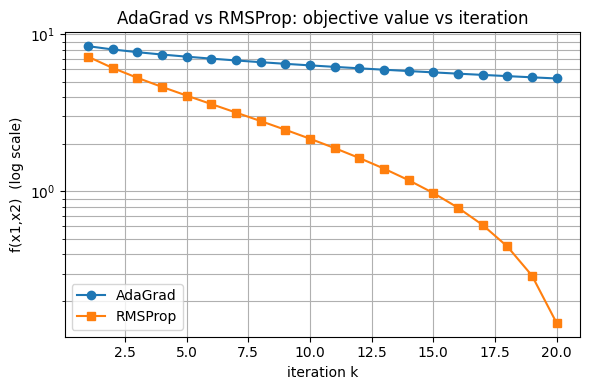

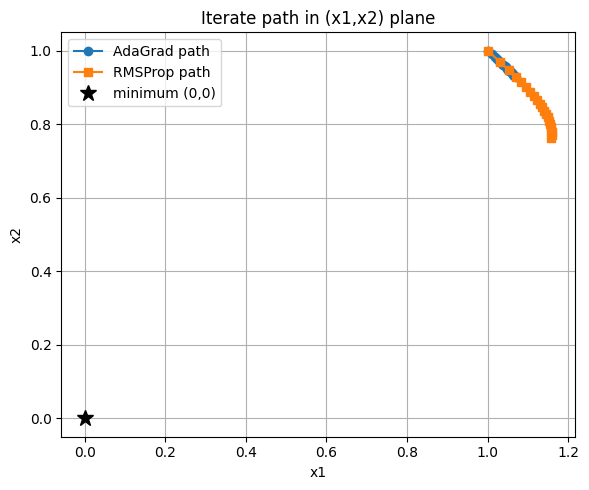

Final AdaGrad point: [1.06941519 0.9280679 ]  f= 5.237692979087319
Final RMSProp point: [1.15803042 0.76263765]  f= 0.14555075515107152


In [ ]:
plt.figure(figsize=(6,4))
plt.plot(adagrad_table.index, adagrad_table['f'], marker='o', label='AdaGrad')
plt.plot(rmsprop_table.index, rmsprop_table['f'], marker='s', label='RMSProp')
plt.yscale('log')
plt.xlabel('iteration k'); plt.ylabel('f(x1,x2)  (log scale)')
plt.title('AdaGrad vs RMSProp: objective value vs iteration')
plt.legend(); plt.grid(True, which='both')
plt.tight_layout(); plt.show()

plt.figure(figsize=(6,5))
plt.plot([1.0]+list(adagrad_table['x1']), [1.0]+list(adagrad_table['x2']), marker='o', label='AdaGrad path')
plt.plot([1.0]+list(rmsprop_table['x1']), [1.0]+list(rmsprop_table['x2']), marker='s', label='RMSProp path')
plt.plot(0,0,'k*', markersize=12, label='minimum (0,0)')
plt.xlabel('x1'); plt.ylabel('x2')
plt.title('Iterate path in (x1,x2) plane')
plt.legend(); plt.grid(True)
plt.tight_layout(); plt.show()

print("Final AdaGrad point:", adagrad_table.iloc[-1][['x1','x2']].values, " f=", adagrad_table.iloc[-1]['f'])
print("Final RMSProp point:", rmsprop_table.iloc[-1][['x1','x2']].values, " f=", rmsprop_table.iloc[-1]['f'])

### Part 4 — AdaGrad vs RMSProp: which is better, and why

After 20 iterations $f_{\text{AdaGrad}}\approx 5.24$ vs $f_{\text{RMSProp}}\approx 0.146$ — **RMSProp is roughly 36× closer to the minimum**.

The reason is how each method's accumulator $A$ behaves:

- **AdaGrad** sums squared gradients over *all* history with no decay, so along the steep $x_2$ direction $A_{x_2}$ grows essentially monotonically and unboundedly (16 → 3136 → ... → 45873 over 20 steps). This keeps shrinking the effective step $\alpha/\sqrt{A_{x_2}}$ every iteration, so the update along $x_2$ **stalls prematurely** even though $|f_{x_2}|$ is still large (still ~43 at k=20).
- **RMSProp** uses an exponential moving average ($\rho=0.9$), so $A_{x_2}$ tracks *recent* gradient magnitude rather than the full history — it peaks around $k\approx9$ (~1002) and then **decreases** as the gradient shrinks (down to ~715 by k=20). The effective step size doesn't collapse the way AdaGrad's does, so RMSProp keeps making meaningful progress along the steep direction throughout, closing in on the origin much faster.

This matches the curvature argument in Part 1: the direction with much larger curvature ($x_2$) is exactly where AdaGrad's non-decaying accumulator over-penalizes the step size, while RMSProp's decaying accumulator adapts to the *current* local curvature instead of the entire trajectory.